CNNs


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import time

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda:0


Data Preparation

In [5]:
# CIFAR-10 normalization statistics
stats = ((0.4914, 0.4822, 0.4465),
         (0.2023, 0.1994, 0.2010))

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(*stats)
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(*stats)
])

batch_size = 64

Data Loaders

In [6]:
trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform_train
)

trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
)

testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform_test
)

testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

100%|██████████| 170M/170M [00:13<00:00, 12.8MB/s]


CNN Architecture

In [7]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        # Block 1
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Block 2
        self.block2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Block 3
        self.block3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.dropout = nn.Dropout(0.5)

        self.fc = nn.Sequential(
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)

        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = self.fc(x)

        return x

model = SimpleCNN().to(device)
print(model)

SimpleCNN(
  (block1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(1

Training Function

In [8]:
def train_model(model, train_loader, test_loader, epochs=15, lr=0.001):

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    train_losses = []
    test_accs = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        # Evaluation
        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs, 1)

                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        acc = 100 * correct / total
        avg_loss = running_loss / len(train_loader)

        train_losses.append(avg_loss)
        test_accs.append(acc)

        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Loss: {avg_loss:.4f} | Test Acc: {acc:.2f}%")

    return train_losses, test_accs

Training

In [9]:
model = SimpleCNN().to(device)

losses, accuracies = train_model(
    model,
    trainloader,
    testloader,
    epochs=15,
    lr=0.001
)


Epoch [1/15] Loss: 1.6089 | Test Acc: 55.98%
Epoch [2/15] Loss: 1.1776 | Test Acc: 58.79%
Epoch [3/15] Loss: 0.9885 | Test Acc: 70.16%
Epoch [4/15] Loss: 0.8799 | Test Acc: 73.53%
Epoch [5/15] Loss: 0.7932 | Test Acc: 77.73%
Epoch [6/15] Loss: 0.7153 | Test Acc: 78.21%
Epoch [7/15] Loss: 0.6578 | Test Acc: 81.27%
Epoch [8/15] Loss: 0.5976 | Test Acc: 81.31%
Epoch [9/15] Loss: 0.5588 | Test Acc: 82.63%
Epoch [10/15] Loss: 0.5147 | Test Acc: 82.78%
Epoch [11/15] Loss: 0.4769 | Test Acc: 85.57%
Epoch [12/15] Loss: 0.4532 | Test Acc: 83.98%
Epoch [13/15] Loss: 0.4279 | Test Acc: 84.33%
Epoch [14/15] Loss: 0.4123 | Test Acc: 85.44%
Epoch [15/15] Loss: 0.3890 | Test Acc: 85.53%


Visualization

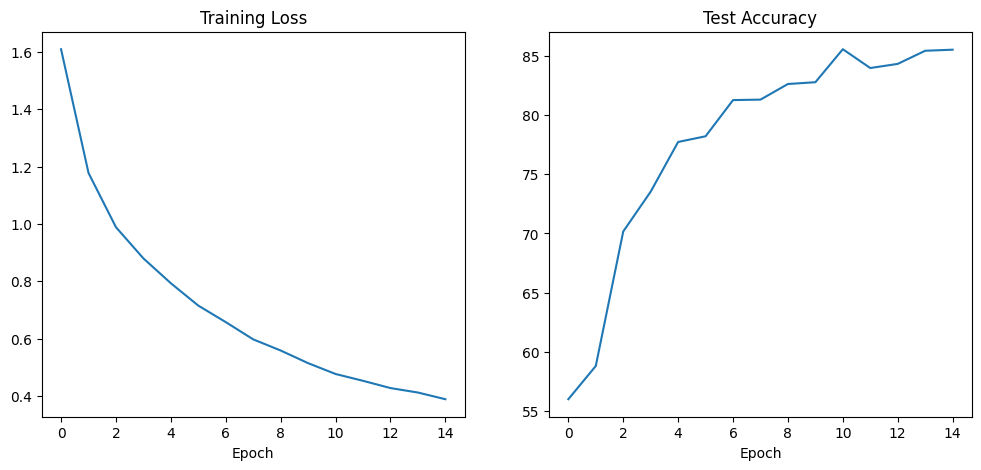

In [10]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")

plt.subplot(1,2,2)
plt.plot(accuracies)
plt.title("Test Accuracy")
plt.xlabel("Epoch")

plt.savefig("results.png")
plt.show()